# Permutations

## Example 1: Verification for the Card Example ($n=5$, $k=3$)

**Task 1.1: Find the answer of the following question**

To do: replace `...` below to complete the task

**Question 1:** We have five distinct cards labeled $1, 2, 3, 4, 5$. We select three cards, and the sequence/order of selection is important. What is the total possible ways to arrange the cards?

**Hints:**
- When selecting $k$ distinct items from a set of $n$ distinct items with order preserved, this count is called a permutation, denoted $\boldsymbol{{}_n P_k}$.
- $$\begin{aligned}
_n P_k &= n\,(n-1)\,(n-2)\cdots(n-k+1), \quad \text{for } k \le n \\
&= \frac{n!}{(n-k)!}
\end{aligned}$$

- `math.factorial(n)` calculates $n!$ for a nonnegative intger $n$.
- `//` is the **floor division operator**, which divides two numbers and rounds the result down to the nearest whole integer.

In [ ]:
import math

def perm(n, k):
    # Task 1.1.1: Integer division for whole-number permutation counts
    return math.factorial(n) // math.factorial(n - k)

# Task 1.1.2: Evaluate textbook example
card_arrangements = perm(5, 3)
print(f"Number of possible ways = {card_arrangements}")

Number of possible ways = 60


**Task 1.2: Visualizing All Permutations in Question 1**

To do: replace `...` below to complete the task

Use `for` loop to display ALL of the distinct ordered arrangements that contribute to the total count.

**Hints:**
- `itertools.permutations(iterable, r)` return successive `r` length permutations of elements from the `iterable`. \
(documentation: https://docs.python.org/3/library/itertools.html)

In [ ]:
import itertools

# Task 1.2.1: Parameters for the example (5 cards, choose 3)
cards = [1, 2, 3, 4, 5]
k = 3

# Task 1.2.2: Generate all permutations
all_permutations = list(itertools.permutations(cards, k))

print(f"Total number of distinct ordered arrangements (permutations): {len(all_permutations)}")
print("\n--- Complete List of All Permutations ---")

# Task 1.2.3: Display all permutations
for i, p in enumerate(all_permutations):
    print(f"  Permutation {i+1:2d}: {p}")

Total number of distinct ordered arrangements (permutations): 60

--- Complete List of All Permutations ---
  Permutation  1: (1, 2, 3)
  Permutation  2: (1, 2, 4)
  Permutation  3: (1, 2, 5)
  Permutation  4: (1, 3, 2)
  Permutation  5: (1, 3, 4)
  Permutation  6: (1, 3, 5)
  Permutation  7: (1, 4, 2)
  Permutation  8: (1, 4, 3)
  Permutation  9: (1, 4, 5)
  Permutation 10: (1, 5, 2)
  Permutation 11: (1, 5, 3)
  Permutation 12: (1, 5, 4)
  Permutation 13: (2, 1, 3)
  Permutation 14: (2, 1, 4)
  Permutation 15: (2, 1, 5)
  Permutation 16: (2, 3, 1)
  Permutation 17: (2, 3, 4)
  Permutation 18: (2, 3, 5)
  Permutation 19: (2, 4, 1)
  Permutation 20: (2, 4, 3)
  Permutation 21: (2, 4, 5)
  Permutation 22: (2, 5, 1)
  Permutation 23: (2, 5, 3)
  Permutation 24: (2, 5, 4)
  Permutation 25: (3, 1, 2)
  Permutation 26: (3, 1, 4)
  Permutation 27: (3, 1, 5)
  Permutation 28: (3, 2, 1)
  Permutation 29: (3, 2, 4)
  Permutation 30: (3, 2, 5)
  Permutation 31: (3, 4, 1)
  Permutation 32: (3, 4,

**Task 1.3: Tree Diagram for Permutation Choices**

This tree diagram illustrates the sequential choices and the multiplication principle.

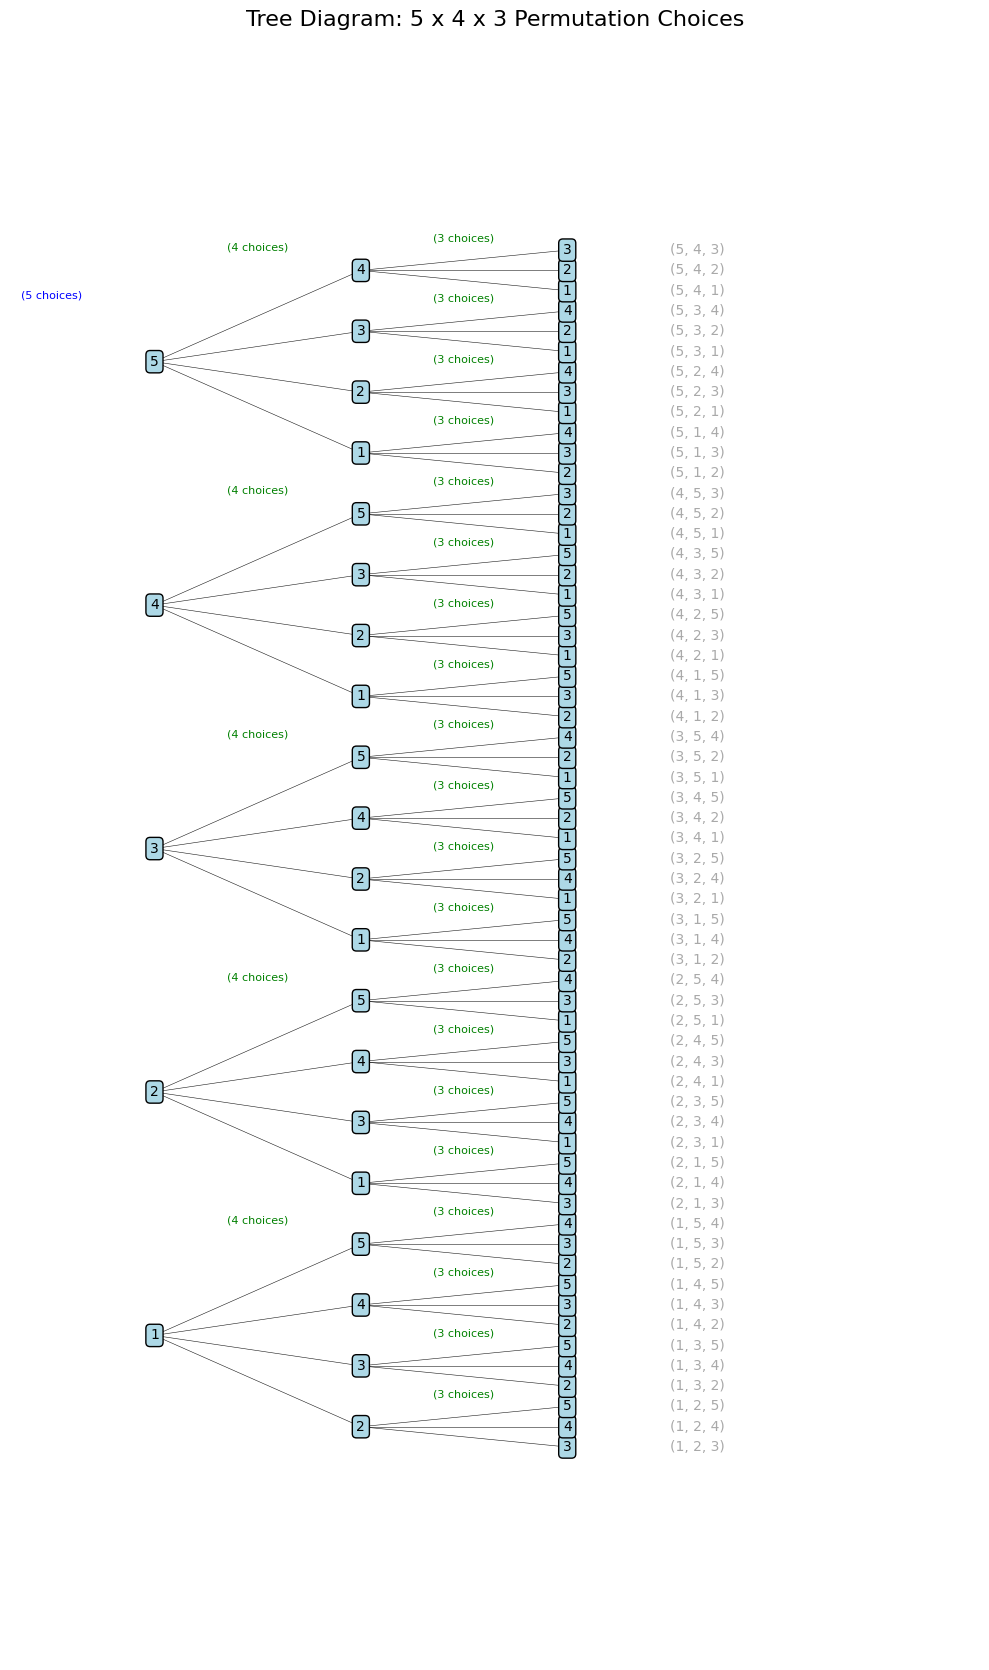

In [ ]:
import matplotlib.pyplot as plt
import math

# Task 1.3.1: Define cards and k from previous cells
cards = [1, 2, 3, 4, 5]
k = 3

# Task 1.3.2: Calculate total number of permutations to set appropriate vertical scaling
def perm(n, k):
    return math.factorial(n) // math.factorial(n - k)

total_permutations = perm(len(cards), k)

# Task 1.3.3: Display the tree diagram
vertical_unit_per_permutation = 0.4
total_diagram_height = total_permutations * vertical_unit_per_permutation * 0.7
fig, ax = plt.subplots(figsize=(10, total_diagram_height))
level_x_spacing = 1.5
min_x_coord = -0.7 * level_x_spacing
max_x_coord = (k * level_x_spacing) + (level_x_spacing * 1.0)
ax.set_xlim(min_x_coord, max_x_coord)
ax.set_ylim(-total_diagram_height * 0.1, total_diagram_height * 1.1)
ax.axis('off')

ax.set_title('Tree Diagram: 5 x 4 x 3 Permutation Choices', fontsize=16, pad=8)

def draw_tree_level(ax, current_cards, path, level, y_center_of_parent_node, y_span_allocated_to_this_parent):
    """
    Draws a level of the permutation tree.

    Args:
        ax: Matplotlib axes object.
        current_cards: The original set of cards.
        path: The current permutation path built so far (parent path).
        level: The current depth in the tree (0-indexed).
        y_center_of_parent_node: The y-coordinate of the parent node (at x_level - 1).
                            Used for drawing connection lines and positioning 'choices' label.
        y_span_allocated_to_this_parent: The total vertical span allocated for all children
                                         branches originating from this parent node.
    """
    x_coord_current_level_nodes = level * level_x_spacing

    if level == k:
        ax.text(x_coord_current_level_nodes - (0.5 * level_x_spacing), y_center_of_parent_node, f'({', '.join(map(str, path))})', ha='left', va='center', fontsize=10, color='darkgray') # Further reduced fontsize
        return 1

    num_drawn_children = 0
    available_choices = [c for c in current_cards if c not in path]
    total_choices_from_this_parent = len(available_choices)

    if total_choices_from_this_parent == 0:
        return 0

    if level < k:
        text_color = 'blue' if level == 0 else 'green'
        label_x_pos = x_coord_current_level_nodes - (0.5 * level_x_spacing)
        label_y_pos = y_center_of_parent_node + y_span_allocated_to_this_parent * 0.45
        ax.text(label_x_pos, label_y_pos, f'({total_choices_from_this_parent} choices)',
                ha='center', va='bottom', fontsize=8, color=text_color)

    y_span_per_child = y_span_allocated_to_this_parent / total_choices_from_this_parent

    for i, choice in enumerate(available_choices):
        new_path = path + [choice]
        child_y_center = (y_center_of_parent_node - y_span_allocated_to_this_parent / 2) + (i + 0.5) * y_span_per_child

        ax.text(x_coord_current_level_nodes, child_y_center, str(choice), ha='center', va='center',
                bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=10) # Further reduced fontsize

        if level > 0:
            x_coord_parent_level_nodes = (level - 1) * level_x_spacing
            ax.plot([x_coord_parent_level_nodes, x_coord_current_level_nodes], [y_center_of_parent_node, child_y_center], 'k-',
                    linewidth=0.4, alpha=0.9)

        drawn_in_branch = draw_tree_level(ax, current_cards, new_path, level + 1, child_y_center, y_span_per_child)
        num_drawn_children += drawn_in_branch
    return num_drawn_children

initial_y_span_for_all_children_of_root = total_diagram_height * 0.9
initial_y_center_of_conceptual_root = total_diagram_height * 0.5

draw_tree_level(ax, cards, [], 0, initial_y_center_of_conceptual_root, initial_y_span_for_all_children_of_root)

plt.tight_layout()
plt.show()

# Combinations

## Example 2: Verification for the Card Example ($n=5$, $k=3$) and Tie Example ($n=500$, $k=5$)

**Task 2.1: Find the answer of the following questions**

To do: replace `...` below to complete the task

**Question 2.1:** Find the number of unordered ways to pick $3$ cards from $5$ distinct cards labeled as $1,2,3,4,5$.

**Question 2.2:** Find the number of unordered ways to pick $5$ ties from $500$ total ties.

**Hints:**
- When choosing $k$ items from $n$ distinct items with no regard to order, the combination count is denoted ${}_n C_k$ (also written binomial coefficient $\dbinom{n}{k}$).
- $$
{}_n C_k = \frac{{}_n P_k}{k!} = \frac{n!}{(n-k)!\,k!} = \binom{n}{k},\quad \text{for } k\le n
$$

In [ ]:
import math

def comb(n, k):
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

# Task 2.1: Evaluate examples
card_groups = comb(5, 3)
tie_choices = comb(500, 5)

print(f"Number of card groups = {card_groups}")
print(f"Number of tie selections = {tie_choices}")

Number of card groups = 10
Number of tie selections = 255244687600


**Task 2.2: Visualizing All Combinations in Question 2.1**

To do: replace `...` below to complete the task

Use `for` loop to display ALL of the distinct unordered selections that contribute to the total count.

**Hints:**
- `itertools.combinations(iterable, r)` return successive `r` length subsequences of elements from input `iterable`. \
(documentation: https://docs.python.org/3/library/itertools.html)

In [ ]:
import itertools

# Task 2.2.1: Parameters for the example (5 cards, choose 3)
cards = [1, 2, 3, 4, 5]
k = 3

# Task 2.2.2: Generate all combinations
all_combinations = list(itertools.combinations(cards, k))

print(f"Total number of distinct unordered selections (combinations): {len(all_combinations)}")
print("\n--- Complete List of All Combinations ---")

# Task 2.2.3: Display all combinations
for i, c in enumerate(all_combinations):
    print(f"  Combination {i+1:2d}: {c}")

Total number of distinct unordered selections (combinations): 10

--- Complete List of All Combinations ---
  Combination  1: (1, 2, 3)
  Combination  2: (1, 2, 4)
  Combination  3: (1, 2, 5)
  Combination  4: (1, 3, 4)
  Combination  5: (1, 3, 5)
  Combination  6: (1, 4, 5)
  Combination  7: (2, 3, 4)
  Combination  8: (2, 3, 5)
  Combination  9: (2, 4, 5)
  Combination 10: (3, 4, 5)


# Permutations and Combinations with Repetition

## Example 3: Permutations with Repetition (Repeated Permutation): Symbol $\boldsymbol{{}_n \Pi_k}$

**Task 3.1: Find the answer of the following question**

To do: replace `...` below to complete the task

**Question 3:** Select $3$ numbers from $\{1,2,3,4,5\}$, arrange them sequentially to form three-digit natural numbers (repetition permitted).
How many such three-digit numbers are multiples of $5$?

**Hints:**
- ${}_n \Pi_k$ denotes ordered selection of $k$ items from $n$ distinct types, where items may be reused (repetition allowed).
- $$
\boldsymbol{{}_n \Pi_k = n^k}
$$

In [ ]:
import math

# Task 3.1: Permutation with repetition
def perm_rep(n, k):
    return n ** k

three_digit_multiples = perm_rep(5,2)

print(f"Answer of Question 3 (3-digit multiples of 5): {three_digit_multiples}")

Answer of Question 3 (3-digit multiples of 5): 25


**Task 3.2: Visualizing All Repeated Permutations in Question 3**

To do: replace `...` below to complete the task

Use `for` loop to display ALL of the distinct arrangements that contribute to the total count.

**Hints:**
- `itertools.product(iterable, repeat = k)` return Cartesian product of the input `iterable`.`. \
(documentation: https://docs.python.org/3/library/itertools.html)

- `list.append(item)` appends item `item` in the list `list`

In [ ]:
import itertools

# Task 3.2: Define parameters and generate all repeated permutations
cards = [1, 2, 3, 4, 5]
k = 3
all_repeated_permutations = list(itertools.product(cards, repeat=k))

multiples_of_5 = []   # Initialize the result list

for p in all_repeated_permutations:
    if p[2] == 5:
        # Convert the tuple to a 3-digit number
        number = p[0] * 100 + p[1] * 10 + p[2]
        multiples_of_5.append(number)   # Append to the result list

print(f"Total number of 3-digit multiples of 5: {len(multiples_of_5)}")
print("\n--- Complete List of 3-Digit Multiples of 5 ---")
for i, num in enumerate(multiples_of_5):
    print(f"  Multiple {i+1:2d}: {num}")

Total number of 3-digit multiples of 5: 25

--- Complete List of 3-Digit Multiples of 5 ---
  Multiple  1: 115
  Multiple  2: 125
  Multiple  3: 135
  Multiple  4: 145
  Multiple  5: 155
  Multiple  6: 215
  Multiple  7: 225
  Multiple  8: 235
  Multiple  9: 245
  Multiple 10: 255
  Multiple 11: 315
  Multiple 12: 325
  Multiple 13: 335
  Multiple 14: 345
  Multiple 15: 355
  Multiple 16: 415
  Multiple 17: 425
  Multiple 18: 435
  Multiple 19: 445
  Multiple 20: 455
  Multiple 21: 515
  Multiple 22: 525
  Multiple 23: 535
  Multiple 24: 545
  Multiple 25: 555


**Task 3.3: Tree Diagram for repeated premutation arrangements**

This tree diagram visually represents the formation of $3$-digit numbers from the set $\{1, 2, 3, 4, 5\}$ with repetition allowed which are multiples of $5$.

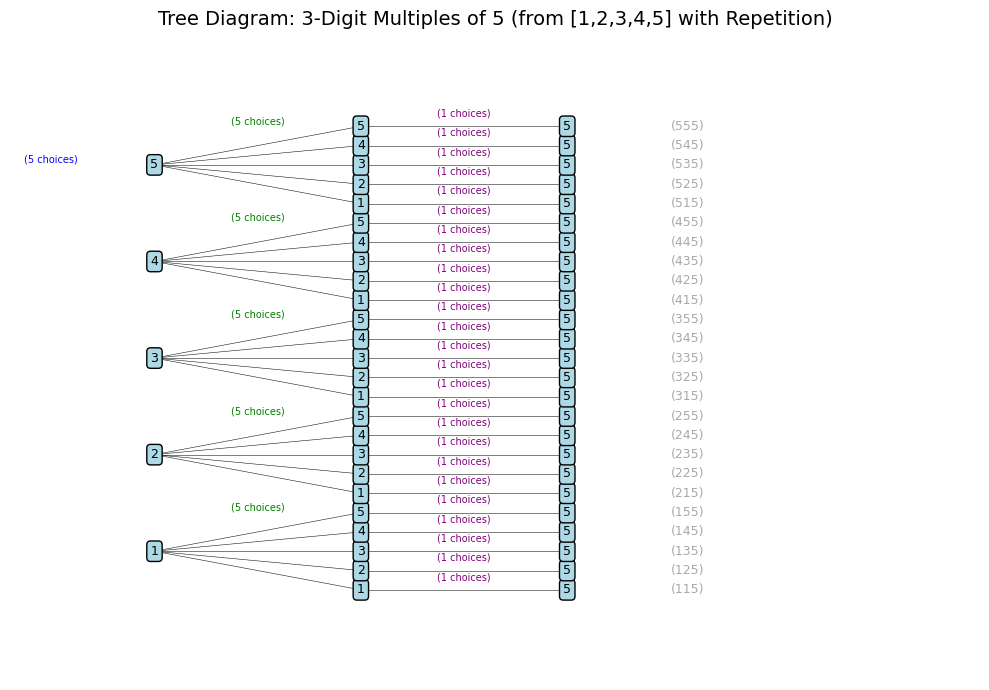

In [ ]:
import matplotlib.pyplot as plt

# Task 3.3.1: Define cards and k for this problem
cards = [1, 2, 3, 4, 5]
k = 3  # 3-digit numbers

# The number of valid permutations with repetition that are multiples of 5 is 5 * 5 * 1 = 25
total_multiples_of_5 = 25

# Task 3.3.2: Display the tree diagram
vertical_unit_per_final_number = 0.4 # Adjust as needed for spacing
total_diagram_height = total_multiples_of_5 * vertical_unit_per_final_number * 0.7 # Scaling factor
fig, ax = plt.subplots(figsize=(10, total_diagram_height))

level_x_spacing = 1.5
min_x_coord = -0.7 * level_x_spacing
max_x_coord = (k * level_x_spacing) + (level_x_spacing * 1.0)
ax.set_xlim(min_x_coord, max_x_coord)
ax.set_ylim(-total_diagram_height * 0.1, total_diagram_height * 1.1)
ax.axis('off')

ax.set_title('Tree Diagram: 3-Digit Multiples of 5 (from [1,2,3,4,5] with Repetition)', fontsize=14, pad=8)

def get_choices_for_level(level, all_cards):
    if level == 0 or level == 1: # First or second digit can be any of the cards
        return all_cards
    elif level == 2: # Third digit must be 5 for multiples of 5
        return [5]
    return []

def draw_tree_level_multiples_of_5(ax, path, level, y_center_of_parent_node, y_span_allocated_to_this_parent, all_cards):
    x_coord_current_level_nodes = level * level_x_spacing

    current_level_choices = get_choices_for_level(level, all_cards)

    if level == k: # Reached the end of a 3-digit number
        num_str = "".join(map(str, path))
        ax.text(x_coord_current_level_nodes - (0.5 * level_x_spacing), y_center_of_parent_node, f'({num_str})', ha='left', va='center', fontsize=9, color='darkgray')
        return 1 # This is a valid leaf node

    total_choices_from_this_level = len(current_level_choices)

    if total_choices_from_this_level == 0:
        return 0

    # Display '(X choices)' label at decision points
    if level < k :
        text_color = 'blue' if level == 0 else 'green' if level == 1 else 'purple'
        label_x_pos = x_coord_current_level_nodes - (0.5 * level_x_spacing)
        label_y_pos = y_center_of_parent_node + y_span_allocated_to_this_parent / 2 - (y_span_allocated_to_this_parent * 0.1) # Adjusted for top alignment
        ax.text(label_x_pos, label_y_pos, f'({total_choices_from_this_level} choices)',
                ha='center', va='bottom', fontsize=7, color=text_color)

    y_span_per_child = y_span_allocated_to_this_parent / total_choices_from_this_level
    num_drawn_children = 0

    for i, choice in enumerate(current_level_choices):
        new_path = path + [choice]
        child_y_center = (y_center_of_parent_node - y_span_allocated_to_this_parent / 2) + (i + 0.5) * y_span_per_child

        ax.text(x_coord_current_level_nodes, child_y_center, str(choice), ha='center', va='center',
                bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=9)

        if level > 0:
            x_coord_parent_level_nodes = (level - 1) * level_x_spacing
            ax.plot([x_coord_parent_level_nodes, x_coord_current_level_nodes], [y_center_of_parent_node, child_y_center], 'k-',
                    linewidth=0.4, alpha=0.9)

        drawn_in_branch = draw_tree_level_multiples_of_5(ax, new_path, level + 1, child_y_center, y_span_per_child, all_cards)
        num_drawn_children += drawn_in_branch
    return num_drawn_children

initial_y_span_for_all_children_of_root = total_diagram_height * 0.9
initial_y_center_of_conceptual_root = total_diagram_height * 0.5

# Initial call for Level 0
draw_tree_level_multiples_of_5(ax, [], 0, initial_y_center_of_conceptual_root, initial_y_span_for_all_children_of_root, cards)

plt.tight_layout()
plt.show()

## Example 4: Combinations with Repetition (Repeated Combination): Symbol ${{}_n H_k}$

**Task 4.1: Find the answer of the following question**

To do: replace `...` below to complete the task

**Question 4:** Four people cast anonymous votes for one of three candidates: A, B, C. Find the total number of distinct vote outcome distributions.

**Hints:**
- ${}_n H_k$ denotes unordered selection of $k$ items from $n$ distinct types, where items may be reused (repetition allowed).
The formula transforms to a standard binomial coefficient:
- $$
{{}_n H_k = \binom{n+k-1}{k}}
$$

In [ ]:
import math

# Combination with repetition: C(n+k-1, k)
def comb_rep(n, k):
    return math.comb(n + k - 1, k)

total_votes = comb_rep(3,4)

print(f"Answer of Question 4 (4 votes,3 candidates): {total_votes}")

Answer of Question 4 (4 votes,3 candidates): 15


**Task 4.2: Visualizing All Repeated Combinations in Question 4**

To do: replace `...` below to complete the task

Use `for` loop to display ALL of the distinct selections that contribute to the total count.

**Hints:**
- `itertools.combinations_with_replacement(iterable, r)` return `r` length subsequences of elements from the input `iterable` allowing individual elements to be repeated more than once.\
(documentation: https://docs.python.org/3/library/itertools.html)

In [ ]:
import itertools
import math

candidates = ['A', 'B', 'C']
num_votes = 4

# Generate all combinations with replacement
all_combinations_rep = list(itertools.combinations_with_replacement(candidates, num_votes))

print(f"Total number of distinct vote outcome distributions: {len(all_combinations_rep)}")
print("\n--- Complete List of Vote Outcome Distributions ---")

for i, combo in enumerate(all_combinations_rep):
    # Count occurrences for each candidate to show the distribution
    counts = {cand: combo.count(cand) for cand in candidates}
    distribution_str = '  '.join([f"{cand}:{counts[cand]}" for cand in candidates])
    print(f"  Distribution {i+1:2d}: {distribution_str} (as {''.join(combo)})")


Total number of distinct vote outcome distributions: 15

--- Complete List of Vote Outcome Distributions ---
  Distribution  1: A:4  B:0  C:0 (as AAAA)
  Distribution  2: A:3  B:1  C:0 (as AAAB)
  Distribution  3: A:3  B:0  C:1 (as AAAC)
  Distribution  4: A:2  B:2  C:0 (as AABB)
  Distribution  5: A:2  B:1  C:1 (as AABC)
  Distribution  6: A:2  B:0  C:2 (as AACC)
  Distribution  7: A:1  B:3  C:0 (as ABBB)
  Distribution  8: A:1  B:2  C:1 (as ABBC)
  Distribution  9: A:1  B:1  C:2 (as ABCC)
  Distribution 10: A:1  B:0  C:3 (as ACCC)
  Distribution 11: A:0  B:4  C:0 (as BBBB)
  Distribution 12: A:0  B:3  C:1 (as BBBC)
  Distribution 13: A:0  B:2  C:2 (as BBCC)
  Distribution 14: A:0  B:1  C:3 (as BCCC)
  Distribution 15: A:0  B:0  C:4 (as CCCC)


# Probability

## Example 5: Probability of Drawing Two Same-Colored Balls

**Task 5.1: Find the answer of the following question**

To do: replace `...` below to complete the task

**Question 5:** A pocket contains $3$ black balls, $2$ white balls, and $1$ red ball (total of $3+2+1=6$ balls). Two balls are drawn simultaneously at random. Calculate the probability that the two selected balls share the same color.

**Hints:**
- The classical probability of event $A$, written $P(A)$, is defined as:
$$
P(A) = \frac{\text{number of favorable outcomes for }A}{\text{total number of possible outcomes}}
= {\frac{n(A)}{n(S)}}
$$

In [ ]:
import math

def binom(n, k):
    """Binomial coefficient C(n,k) = n!/(k!*(n-k)!)"""
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

# Task 5.1.1: Total ways to pick 2 balls from 6
total = binom(6, 2)
print(f"Total unordered pairs = {total}")

# Task 5.1.2: Favorable same-color pairs
black_pairs = binom(3, 2)
white_pairs = binom(2, 2)
favorable = black_pairs + white_pairs

print(f"Black pairs = {black_pairs}")
print(f"White pairs = {white_pairs}")
print(f"Total favorable same-color pairs = {favorable}")

# Task 5.1.3: Probability
prob = favorable / total

print(f"\n(Analytical) Probability (two same color) = {favorable}/{total} = {prob:.4f}")

Total unordered pairs = 15
Black pairs = 3
White pairs = 1
Total favorable same-color pairs = 4

(Analytical) Probability (two same color) = 4/15 = 0.2667


**Task 5.2: Simulation for Probability**

To do: replace `...` below to complete the task

We simulate $500$ repeated experiments of drawing two same-colored balls using the Python programming language to observe relative frequency (statistical probability).

**Hints:**
- `random.sample(population, k)` returs a `k` length list of unique elements chosen from the `population` sequence. Used for random sampling **without replacement**. \
(documentation: https://docs.python.org/3.14/library/random.html)

In [ ]:
import random

# Task 5.2.1: Problem parameters from the original question
black_balls = 3
white_balls = 2
red_balls = 1
balls_to_draw = 2

# Task 5.2.2: Create the 'urn' or 'pocket' of balls
urn = ['B'] * black_balls + ['W'] * white_balls + ['R'] * red_balls

num_simulations = 500
same_color_count = 0    # Initialize the counter

print(f"## Simulation (Showing Each Draw)\n")
print(f"Urn: {urn}, Drawing: {balls_to_draw}, Simulations: {num_simulations}\n")

for i in range(num_simulations):
    # Task 5.2.3.1: Randomly draw two balls without replacement
    drawn_balls = random.sample(urn, balls_to_draw)

    # Task 5.2.3.2: Check if the drawn balls are of the same color
    is_same_color = (drawn_balls[0] == drawn_balls[1])
    if is_same_color:
        same_color_count += 1

    # Task 5.2.3.3: Print each draw
    print(f"  Draw {i+1:2d}: {drawn_balls} -> Same Color: {is_same_color}")

# Task 5.2.3: Calculate the estimated probability
simulated_probability = same_color_count / num_simulations

print(f"\n--- Simulation Results ---")
print(f"Total same color draws: {same_color_count}")
print(f"Estimated Probability: {simulated_probability:.4f}")

anaytical_probability = prob
print(f"Analytical Probability: {anaytical_probability:.4f} (from Task 5.1)")

## Simulation (Showing Each Draw)

Urn: ['B', 'B', 'B', 'W', 'W', 'R'], Drawing: 2, Simulations: 500

  Draw  1: ['R', 'B'] -> Same Color: False
  Draw  2: ['W', 'W'] -> Same Color: True
  Draw  3: ['R', 'B'] -> Same Color: False
  Draw  4: ['B', 'B'] -> Same Color: True
  Draw  5: ['W', 'W'] -> Same Color: True
  Draw  6: ['R', 'W'] -> Same Color: False
  Draw  7: ['B', 'W'] -> Same Color: False
  Draw  8: ['B', 'B'] -> Same Color: True
  Draw  9: ['B', 'B'] -> Same Color: True
  Draw 10: ['W', 'B'] -> Same Color: False
  Draw 11: ['R', 'W'] -> Same Color: False
  Draw 12: ['W', 'B'] -> Same Color: False
  Draw 13: ['B', 'W'] -> Same Color: False
  Draw 14: ['B', 'R'] -> Same Color: False
  Draw 15: ['B', 'W'] -> Same Color: False
  Draw 16: ['B', 'B'] -> Same Color: True
  Draw 17: ['B', 'B'] -> Same Color: True
  Draw 18: ['W', 'B'] -> Same Color: False
  Draw 19: ['B', 'W'] -> Same Color: False
  Draw 20: ['W', 'W'] -> Same Color: True
  Draw 21: ['W', 'R'] -> Same Color: False
  D

## Example 6: Coin Flip Simulation with Python Code

**Task 6: Simulation for Probability**

To do: replace `...` below to complete the task

We simulate repeated coin flips using programming language to observe relative frequency (statistical probability).

**Hints:**
- `random.choices(population, k)` return a `k` sized list of elements chosen from the `population` **with replacement**. \
(documentation: https://docs.python.org/3.14/library/random.html)

- `collections.Counter(iterable)` creates a dictionary-like object that counts the occurrences of items in `iterable`. \
(doumentation: https://docs.python.org/3/library/collections.html)

- `.get(key)` is a dictionary method used to retrieve the value associated with given `key`.

In [ ]:
import random
import collections

def flip_coins(num_trials):
    # This function simulates coin flips and calculates the frequency of heads.

    # Task 6.1: Simulate `num_trials` coin flips.
    # Each flip should be either "head" or "tail".
    # Hint: Use `random.choices(population, k=number_of_choices)`
    outcomes = random.choices(["head", "tail"], k=num_trials)

    # Task 6.2: Count the occurrences of "head" and "tail" in the `outcomes`.
    # Hint: Use `collections.Counter(iterable)` to get counts, and then `.get(key)`.
    counts = collections.Counter(outcomes)
    heads = counts.get("head")
    tails = counts.get("tail")

    # Task 6.3: Calculate the relative frequency of 'heads'.
    freq_head = heads / num_trials

    print(f"\n--- {num_trials} Coin Flips Simulation ---")

    # Task 6.4: Print each individual flip for better understanding.
    for i, outcome in enumerate(outcomes):
        print(f"  Flip {i+1:2d}: {outcome}")

    print(f"Heads count: {heads}, Tails count: {tails}")
    print(f"Relative frequency of Heads = {freq_head:.4f}")

# Task 6.5: Call the `flip_coins` function with 100 trials to run the simulation.
flip_coins(100)


--- 100 Coin Flips Simulation ---
  Flip  1: head
  Flip  2: tail
  Flip  3: head
  Flip  4: tail
  Flip  5: tail
  Flip  6: tail
  Flip  7: head
  Flip  8: tail
  Flip  9: head
  Flip 10: head
  Flip 11: head
  Flip 12: head
  Flip 13: head
  Flip 14: head
  Flip 15: head
  Flip 16: head
  Flip 17: tail
  Flip 18: tail
  Flip 19: head
  Flip 20: tail
  Flip 21: head
  Flip 22: tail
  Flip 23: head
  Flip 24: tail
  Flip 25: head
  Flip 26: tail
  Flip 27: head
  Flip 28: head
  Flip 29: head
  Flip 30: head
  Flip 31: head
  Flip 32: tail
  Flip 33: tail
  Flip 34: head
  Flip 35: head
  Flip 36: tail
  Flip 37: tail
  Flip 38: tail
  Flip 39: head
  Flip 40: head
  Flip 41: head
  Flip 42: tail
  Flip 43: head
  Flip 44: tail
  Flip 45: head
  Flip 46: tail
  Flip 47: head
  Flip 48: tail
  Flip 49: tail
  Flip 50: head
  Flip 51: tail
  Flip 52: head
  Flip 53: head
  Flip 54: tail
  Flip 55: head
  Flip 56: head
  Flip 57: tail
  Flip 58: tail
  Flip 59: tail
  Flip 60: tail
  Fli

## Example 7: Hypergeometric Probability for Defective Products

**Task 7: Find the answers of the following questions**

To do: replace `...` below to complete the task

+ Total products: $1000$

+ Defective products: $3$

+ Normal (non-defective) products: $1000 - 3 = 997$

We randomly select $10$ products without replacement. Compute two probabilities:

**Question 7.1:**  Probability that none of the 10 selected items are defective.

**Question 7.2:** Probability that at least one selected item is defective.


In [ ]:
import math

def binom(n, k):
    """Binomial coefficient C(n,k) = n!/(k! (n-k)!)"""
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

# Given parameters
total = 1000
defective_total = 3
normal_total = total - defective_total
sample_size = 10

# Task 7.1: Probability zero defective
fav_0_def = binom(normal_total, sample_size) * binom(defective_total, 0)
total_ways = binom(total, sample_size)
p0 = fav_0_def / total_ways

print("=== Question 7.1: Probability of 0 defective products ===")
print(f"P(0 defective) = {p0:.7f}\n")

# Task 7.2: Probability at least one defective (complement rule)
p_at_least_1 = 1 - p0

print("=== Question 7.2: Probability of at least 1 defective product ===")
print(f"P(at least 1 defective) = 1 - P(0 defective) = {p_at_least_1:.7f}")

=== Question 7.1: Probability of 0 defective products ===
P(0 defective) = 0.9702695

=== Question 7.2: Probability of at least 1 defective product ===
P(at least 1 defective) = 1 - P(0 defective) = 0.0297305


# Conditional Probability

## Example 8: Conditional Probability Calculation

**Task 8: Find the answer of the following question**

To do: replace `...` below to complete the task

**Question 8:** Given values:
$$
P(A) = \frac{21}{25},\quad P(A\cap B^c) = \frac15
$$

**Goal**: Compute $P(B \mid A)$.

**Hints:**
- `Fraction(a,b)` represents the fraction $\dfrac{a}{b}$. The command allows operations involving fractions are performed with perfect accuracy.

- Complement Partition Identity for Event $A$:
$$
P(A) = P(A \cap B) + P(A \cap B^c)
$$

- Definition for $P(B \mid A)$:
$$
P(B\mid A) = \frac{P(A\cap B)}{P(A)}
$$

In [ ]:
from fractions import Fraction
# Task 8.0: Given input probabilities
P_A = Fraction(21,25)
P_A_and_not_B = Fraction(1,5)

print(f"Given P(A) = {P_A}")
print(f"Given P(A and B^c) = {P_A_and_not_B}")

# Task 8.1: Compute P(A ∩ B) using partition identity
P_A_and_B = P_A - P_A_and_not_B
print(f"Step 1: P(A ∩ B) = {P_A_and_B}")

# Task 8.2: Conditional probability formula P(B|A) = P(A∩B)/P(A)
P_B_given_A = P_A_and_B / P_A
print(f"Step 2: P(B|A) = {P_B_given_A}")

Given P(A) = 21/25
Given P(A and B^c) = 1/5
Step 1: P(A ∩ B) = 16/25
Step 2: P(B|A) = 16/21


# Bayes' Theorem

## Example 9: Bayes' Theorem - Factory Production

**Task 9: Find the answer of the following quesitons**

To do: replace `...` below to complete the task

Three factory machines $A, B, C$ produce $50\%$, $30\%$, and $20\%$ of the total output, respectively.

Defect rates:

*   $P(\text{Defect}\mid A) = 0.04$
*   $P(\text{Defect}\mid B) = 0.03$
*   $P(\text{Defect}\mid C) = 0.02$

**Question 9.1** What is the total probability that a randomly selected product is defective?

**Question 9.2** If a randomly selected product is found to be defective, what is the probability that it was produced by machine $A$?

**Hints:**
* Law of Total Probability:

$$
P(B) = \sum_{i=1}^n P(A_i)\,P(B\mid A_i)
= P(A_1)P(B\mid A_1)+P(A_2)P(B\mid A_2)+\dots+P(A_n)P(B\mid A_n)
$$

* Bayes' Theorem: $$
P(A_j \mid B)
= \frac{P(A_j)\,P(B\mid A_j)}
{\sum_{i=1}^n P(A_i)\,P(B\mid A_i)
}
$$
* Use `Fraction(a,b)` for precise calculations.

In [ ]:
from fractions import Fraction

# Task 9.1. Prior probabilities as exact fractions
P_A = Fraction(50, 100)
P_B = Fraction(30, 100)
P_C = Fraction(20, 100)

# Task 9.2. Conditional defect rates as exact fractions
P_X_given_A = Fraction(4, 100)
P_X_given_B = Fraction(3, 100)
P_X_given_C = Fraction(2, 100)

# Task 9.3: Law of Total Probability for P(X) where X = defect
term_A = P_A * P_X_given_A
term_B = P_B * P_X_given_B
term_C = P_C * P_X_given_C
P_X = term_A + term_B + term_C

print("=== Question 9.1: Total Probability of Defective Product P(X) ===")
print(f"P(X) = {P_X}\n")

# Task 9.4: Bayes' Theorem Posterior P(C|X)
P_C_given_X = term_C / P_X

print("=== Question 9.2: Bayes' Theorem P(C|X) ===")
print(f"P(C|X) = {P_C_given_X}")

=== Question 9.1: Total Probability of Defective Product P(X) ===
P(X) = 33/1000

=== Question 9.2: Bayes' Theorem P(C|X) ===
P(C|X) = 4/33


# Random Variables

## Example 10: Number of Tails in 2 Coin Flips

**Task 10.1: Find the sample space, and PMF of the random variable**

To do: replace `...` below to complete the task

Consider the experiment of flipping two fair coins.
1. Find the sample space of all distinct outcomes (where `"H"` represents Head and `"T"` represents tail)
2. Define random variable $X$ as **count of tails observed in the two coin tosses**.
3. Calculate the probbility mass for each possible $X$ value. $($i.e. $X=0$, $X=1$, $X=2$$)$
4. Verify the total probability sums to 1

**Hints:**
- use dictionary `{key:value}` to store the PMF values
- `dict.values()` retrives the values of dictionary `dict`

In [ ]:
# Task 10.1.1: Find the sample space for two coin flips
sample_space = [("H","H"), ("H","T"), ("T","H"), ("T","T")]
total_outcomes = len(sample_space)

# Task 10.1.2: Define random variable X: count number of tails per outcome
def count_tails(outcome):
    return outcome.count("T")

# Task 10.1.3: Calculate probability mass for each possible X value (0,1,2)
pmf = {0:0, 1:0, 2:0}
for outcome in sample_space:
    x_val = count_tails(outcome)
    pmf[x_val] += 1

for x in pmf:
    pmf[x] = pmf[x] / total_outcomes

# Task 10.1.4: Print step-by-step breakdown
print("=== Random Variable X = Number of Tails in 2 Coin Flips ===")
print(f"Total sample outcomes = {total_outcomes}\n")
for x in sorted(pmf.keys()):
    count = pmf[x] * total_outcomes
    prob = pmf[x]
    print(f"X = {x}: P(X={x}) = {prob:.2f}")

# Task 10.1.5: Verify total probability sums to 1
total_prob = sum(pmf.values())
print(f"\n(Verification) Total sum of all probabilities = {total_prob}")

=== Random Variable X = Number of Tails in 2 Coin Flips ===
Total sample outcomes = 4

X = 0: P(X=0) = 0.25
X = 1: P(X=1) = 0.50
X = 2: P(X=2) = 0.25

(Verification) Total sum of all probabilities = 1.0


**Task 10.2: Run a Monte Carlo Simulation for Coin Flips**

To do: replace `...` below to complete the task

We simulate $10000$ repeated experiments of flipping two fair coins using the Python programming language to observe relative frequency (statistical probability).

**Hints:**
- `random.choices(population)` return an element chosen from the `population`. \
(documentation: https://docs.python.org/3.14/library/random.html)

- Use a dictionary to store the counts of flipping two coins

In [ ]:
# Task 10.2: Monte Carlo Simulation (empirical test of the random variable distribution)
import random

# Task 10.2.1: Create a function simulating a single experiment of flipping two coins
def flip_two_coins():
    coin1 = random.choice(["H","T"])
    coin2 = random.choice(["H","T"])
    return (coin1, coin2)

# Task 10.2.2: Initialize simulation trials and simulation counter
simulation_trials = 10000
sim_counts = {0:0,1:0,2:0}

# Task 10.2.3: Perform the simulations
for _ in range(simulation_trials):
    result = flip_two_coins()
    sim_x = count_tails(result)
    sim_counts[sim_x] += 1

# Task 10.2.4: Print the simulation results
print(f"=== Monte Carlo Simulation ({simulation_trials} trials) ===")
for x in sorted(sim_counts.keys()):
    sim_prob = sim_counts[x] / simulation_trials
    print(f"Simulated P(X = {x}) ≈ {sim_prob:.4f}")

=== Monte Carlo Simulation (10000 trials) ===
Simulated P(X = 0) ≈ 0.2483
Simulated P(X = 1) ≈ 0.5043
Simulated P(X = 2) ≈ 0.2474


# Discrete Probability Distribution

## Example 11: Probability Mass Function (PMF) in Two Coin Flip

**Task 11.1: Create a PMF for number of tails in two coin flips**

To do: replace `...` below to complete the task

Experiment: Flip two fair coins simultaneously. $X$ = number of tails observed.

Sample space: $S=\{(H,H),(H,T),(T,H),(T,T)\}$, each outcome equally likely with probability $\tfrac14$.

**Hint:**
- Probability Mass Function (PMF): $$
f(x) =
\begin{cases}
P(X=x_i) & \text{for } x = x_1,\,x_2,\,\dots,\,x_n \\
0 & \text{for all other real } x
\end{cases}
$$

In [ ]:
# Discrete random variable X: number of tails in two coin flips
# Define possible x values and their pmf f(x)
x_values = [0, 1, 2]
pmf_vals = [1/4, 1/2, 1/4]

# Store as dictionary for easy lookup
pmf = dict(zip(x_values, pmf_vals))

print("=== Discrete PMF for X = Number of Tails (2 coin tosses) ===")
for x, fx in pmf.items():
    print(f"f({x}) = P(X={x}) = {fx:.2f}")

=== Discrete PMF for X = Number of Tails (2 coin tosses) ===
f(0) = P(X=0) = 0.25
f(1) = P(X=1) = 0.50
f(2) = P(X=2) = 0.25


**Task 11.2: Verify the proeprties of PMF**

To do: replace `...` below to complete the task

**Property 11.2.1:** $ 0 \leq f(x) \leq 1 \text{ for all } x$

**Proeprty 11.2.2:** Sum of $f(x) = 1$

**Question 11.2.4:** Compute the probability of $P(0 \leq X \leq 1)$.

In [ ]:
# Property 11.2.1: Check 0 ≤ f(x) ≤ 1 for all x
print("--- Property 11.1 Check (0 ≤ f(x) ≤ 1) ---")
prop1_ok = True           # Initialize the test value
for x, fx in pmf.items():
    if not (0 <= fx <= 1):
        prop1_ok = False
        print(f"ERROR: f({x}) = {fx} out of bounds")
if prop1_ok:
    print("All pmf values satisfy 0 ≤ f(x) ≤ 1")

# Property 11.2.2: Sum f(x) = 1
total_mass = sum(pmf_vals)

print(f"\n--- Property 11.2 Check (Total sum = 1) ---")
print(f"Sum f(x) = {total_mass}")

# Task 11.2.3: Create a function for computing interval probability P(a ≤ X ≤ b)
def prob_interval(a, b, pmf_dict):
    total = 0.0
    for x, fx in pmf_dict.items():
        if a <= x <= b:
            total += fx
    return total

# Question 11.2.4: Compute interval probability P(0 ≤ X ≤ 1)
p_0to1 = prob_interval(0, 1, pmf)

print(f"\n--- Property 11.3 Example ---")
print(f"P(0 ≤ X ≤ 1) = {p_0to1:.2f}")

--- Property 11.1 Check (0 ≤ f(x) ≤ 1) ---
All pmf values satisfy 0 ≤ f(x) ≤ 1

--- Property 11.2 Check (Total sum = 1) ---
Sum f(x) = 1.0

--- Property 11.3 Example ---
P(0 ≤ X ≤ 1) = 0.75


**Task 11.3: Run a Monte Carlo Simulation to approximate PMF**

To do: replace `...` below to complete the task

We simulate $20000$ repeated experiments of flipping two fair coins using the Python programming language to observe relative frequency (statistical probability).

**Hints:**
- `random.choices(population)` return an element chosen from the `population`. \
(documentation: https://docs.python.org/3.14/library/random.html)

- Use a dictionary to store the counts of flipping two coins

In [ ]:
# Task 11.3: Monte Carlo Simulation to approximate PMF
import random

# Task 11.3.1: Create a function simulating a single experiment of flipping two coins
def flip_two():
    c1 = random.choice(["H","T"])
    c2 = random.choice(["H","T"])
    return (c1,c2)

# Task 11.3.2: Create a function to count the number of tails in each experiment
def count_tails(outcome):
    return outcome.count("T")

# Task 11.3.3: Initialize simulation trials and simulation counter
trials = 20000
sim_counts = {0:0,1:0,2:0}

# Task 11.3.4: Perform the simulations
for _ in range(trials):
    result = flip_two()
    x_sim = count_tails(result)
    sim_counts[x_sim] +=1

# Task 11.3.5: Print the simulation results
print(f"=== Monte Carlo Simulation ({trials} trials) ===")
for x in sorted(sim_counts.keys()):
    sim_prob = sim_counts[x] / trials
    print(f"Simulated f({x}) ≈ {sim_prob:.4f}")

=== Monte Carlo Simulation (20000 trials) ===
Simulated f(0) ≈ 0.2584
Simulated f(1) ≈ 0.4979
Simulated f(2) ≈ 0.2437


# Continuous Probability Distributions

## Example 12: Uniform Distribution over $[0,2]$

**Task 12.1: Create a PDF of the Uniform Distribution over $[0,2]$**

To do: replace `...` below to complete the task

PDF:
$$
f(x) =
\begin{cases}
\frac12 & 0 \le x \le 2 \\
0 & \text{otherwise}
\end{cases}
$$

**Hints:**
- `sp.Symbol('x', real=True)` declares `x` as a symbolic variable with real values
- `sp.Rational(p,q)` represents a fraction $\dfrac{p}{q}$
- `sp.Piecewise( (expr,cond), (expr,cond))` represents a piecewise function with expression `expr` and condition `cond`

(documentation: https://docs.sympy.org/latest/index.html)

In [ ]:
import sympy as sp
import scipy.integrate as spi
import numpy as np

# Task 12.1.1: Define symbolic variable
x = sp.Symbol('x', real=True)

# Task 12.1.2: Define uniform pdf f(x) = 1/2 for 0 ≤ x ≤ 2, else 0
def f_sym(x_val):
    if 0 <= x_val <= 2:
        return sp.Rational(1,2)
    else:
        return 0

# Task 12.1.3: Convert to piecewise SymPy expression
f = sp.Piecewise((sp.Rational(1,2), (x >= 0) & (x <= 2)), (0, True))

print("=== Continuous PDF for X = Uniform Distribution (0 to 2) ===")
print("f(x) = ")
sp.pprint(f)

=== Continuous PDF for X = Uniform Distribution (0 to 2) ===
f(x) = 
⎧1/2  for x ≥ 0 ∧ x ≤ 2
⎨                      
⎩ 0       otherwise    


**Task 12.2: Verify the properties of PDF**

To do: replace `...` below to complete the task

**Property 12.2.1:** $f(x) \geq 0 \text{ for all real }x$

test points: $-1, 0, 1, 2, 3$

**Property 12.2.2:** $\displaystyle\int_{-\infty}^\infty f(x) dx = 1$

**Question 12.2.3:** Compute the probability of $P(0.5 \leq X \leq 1.5)$.

**Task 12.2.4:** Verify that the probability of $P(X = 1) = 0$.

**Hints:**
- `f.subs(x, xi)` evaluates the function `f` with symbol `x` with value `xi` \
(documentation: https://docs.sympy.org/latest/modules/core.html)
- `sp.integrate(f, (x, a, b))` returns the definite integral $\int_a^b f(x) dx$ \
(documentation: https://docs.sympy.org/latest/modules/integrals/integrals.html)

- `sp.oo` represents $\infty$ \
(documentation: https://docs.sympy.org/latest/modules/core.html)

In [ ]:
# Task 12.2.1: Test sample points inside and outside support
test_points = [-1, 0, 1, 2, 3]

print("=== Property 12.2.1: Verify PDF Property 1 (f(x) ≥ 0 for all real x) ===")
for xi in test_points:
    fx_val = f.subs(x, xi)
    print(f"f({xi}) = {fx_val}, non-negative? {fx_val >= 0}")

# Property 12.2.2: Integral from -inf to inf = 1
total_integral = sp.integrate(f, (x, -sp.oo, sp.oo))

print("\n=== Property 12.2.2: Verify PDF Property 2 (Integral from -∞ to ∞ = 1) ===")
print(f"Integral from -∞ to ∞ of f(x) dx = {total_integral}")

# Task 12.2.3: Compute the Interval Probability P(0.5 ≤ X ≤ 1.5)
interval_int = sp.integrate(f, (x, 0.5, 1.5))

print("\n=== Property 12.2.3: Verify Interval Probability P(0.5 ≤ X ≤ 1.5) ===")
print(f"P(0.5 ≤ X ≤ 1.5) = Integral from 0.5 to 1.5 of f(x) dx = {float(interval_int)}")

# Task 12.2.4: Verify single point probability P(X=1)=0
point_int = sp.integrate(f, (x, 1, 1))

print(f"\nSingle point integral P(X = 1) = Integral from 1 to 1 of f(x) dx = {point_int}")

=== Property 12.2.1: Verify PDF Property 1 (f(x) ≥ 0 for all real x) ===
f(-1) = 0, non-negative? True
f(0) = 1/2, non-negative? True
f(1) = 1/2, non-negative? True
f(2) = 1/2, non-negative? True
f(3) = 0, non-negative? True

=== Property 12.2.2: Verify PDF Property 2 (Integral from -∞ to ∞ = 1) ===
Integral from -∞ to ∞ of f(x) dx = 1

=== Property 12.2.3: Verify Interval Probability P(0.5 ≤ X ≤ 1.5) ===
P(0.5 ≤ X ≤ 1.5) = Integral from 0.5 to 1.5 of f(x) dx = 0.5

Single point integral P(X = 1) = Integral from 1 to 1 of f(x) dx = 0


**Task 12.3: Plot the PDF and the shaded interval area**

Plot the PDF curve and shaded interval area for Question 12.2.3.

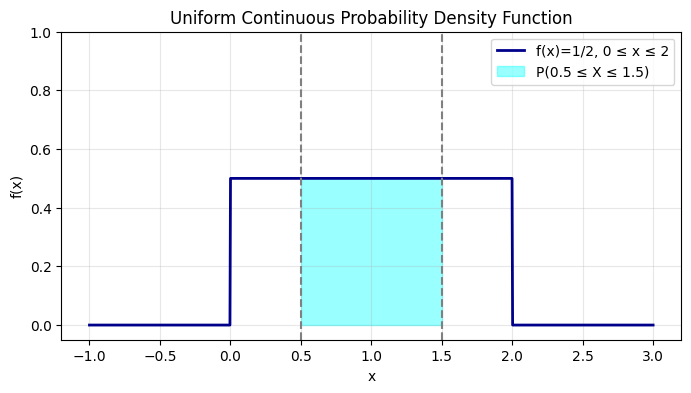

In [ ]:
# Task 12.3: Plot PDF curve and shaded interval area
import matplotlib.pyplot as plt

def pdf_uniform(x_num):
    return 0.5 if (0 <= x_num <=2) else 0

xs = np.linspace(-1, 3, 1000)
ys = np.array([pdf_uniform(t) for t in xs])

plt.figure(figsize=(8,4))
plt.plot(xs, ys, color='darkblue', linewidth=2, label='f(x)=1/2, 0 ≤ x ≤ 2')
x_fill = np.linspace(0.5,1.5,500)
y_fill = np.array([pdf_uniform(t) for t in x_fill])
plt.fill_between(x_fill, y_fill, color='cyan', alpha=0.4, label='P(0.5 ≤ X ≤ 1.5)')
plt.axvline(x=0.5, linestyle='--', color='gray')
plt.axvline(x=1.5, linestyle='--', color='gray')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-0.05, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.title('Uniform Continuous Probability Density Function')
plt.show()